# Viral Content & Social Media Engagement Analysis

### Identifying platform and content patterns with Python and SQL

This portfolio project analyzes **5,000 viral social media posts** published across TikTok, Instagram, Twitter, and YouTube. The goal is to identify engagement patterns, compare platform and content performance, and translate the findings into practical marketing recommendations.

**Tools:** Python, Pandas, Matplotlib, SQLite / SQL  
**Author:** Amy Sulbaran

## Business Questions

1. Which platforms generate the strongest audience engagement?
2. Which content formats perform best?
3. How are views, likes, shares, and comments distributed across platforms?
4. What actions could a marketing team take based on the findings?

## Methodology

The analysis follows five steps:

1. Load and validate the dataset.
2. Standardize column names and data types.
3. Create total engagement and engagement-rate metrics.
4. Compare results using both **mean and median** engagement rates.
5. Validate key findings with SQL and summarize business recommendations.

> **Important metric note:** Some records contain more interactions than views, producing engagement rates above 100%. Because these extreme values strongly affect averages, the analysis reports both the mean and the median. The median is treated as the more robust measure for typical performance.

In [1]:
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

Matplotlib is building the font cache; this may take a moment.


## 1. Load the Data

In [2]:
DATA_CANDIDATES = [
    Path("Cleaned_Viral_Social_Media_Trends.csv"),
    Path("data/Cleaned_Viral_Social_Media_Trends.csv"),
    Path("/mnt/data/Cleaned_Viral_Social_Media_Trends.csv"),
]

DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset not found. Place 'Cleaned_Viral_Social_Media_Trends.csv' "
        "in the same folder as this notebook or inside a data/ folder."
    )

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows and {df.shape[1]} columns from: {DATA_PATH}")
df.head()

Loaded 5,000 rows and 11 columns from: Cleaned_Viral_Social_Media_Trends.csv


,Post_ID,Post_Date,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,2022-01-13,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,2022-05-13,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,2022-01-07,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,2022-12-05,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,2023-03-23,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium


## 2. Data Quality Assessment

In [3]:
quality_summary = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique(),
})

print(f"Duplicate rows: {df.duplicated().sum():,}")
quality_summary

Duplicate rows: 0


,data_type,missing_values,unique_values
Post_ID,object,0,5000
Post_Date,object,0,729
Platform,object,0,4
Hashtag,object,0,10
Content_Type,object,0,6
Region,object,0,8
Views,int64,0,4996
Likes,int64,0,4972
Shares,int64,0,4877
Comments,int64,0,4735


The dataset contains no missing values or exact duplicate rows. Column names are standardized before analysis, and the post date is converted to a proper datetime field.

In [4]:
df = df.copy()
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

df["post_date"] = pd.to_datetime(df["post_date"], errors="coerce")

numeric_columns = ["views", "likes", "shares", "comments"]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

assert df["post_date"].notna().all(), "Some post dates could not be parsed."
assert df[numeric_columns].notna().all().all(), "Some engagement metrics are not numeric."
assert (df["views"] > 0).all(), "Views must be greater than zero."

print("Standardized columns:")
print(df.columns.tolist())

Standardized columns:
['post_id', 'post_date', 'platform', 'hashtag', 'content_type', 'region', 'views', 'likes', 'shares', 'comments', 'engagement_level']


## 3. Feature Engineering

In [5]:
df["engagement_total"] = df[["likes", "shares", "comments"]].sum(axis=1)
df["engagement_rate"] = df["engagement_total"] / df["views"]

df[["views", "likes", "shares", "comments", "engagement_total", "engagement_rate"]].describe()

,views,likes,shares,comments,engagement_total,engagement_rate
count,"5,000.0000","5,000.0000","5,000.0000","5,000.0000","5,000.0000","5,000.0000"
mean,"2,494,066.4440","251,475.0298","50,519.5620","24,888.3938","326,882.9856",0.5676
std,"1,459,489.8244","144,349.5834","29,066.3627","14,284.5043","148,089.9784",4.8621
min,"1,266.0000",490.0000,52.0000,18.0000,"12,418.0000",0.0030
25%,"1,186,207.2500","126,892.2500","25,029.0000","12,305.2500","202,019.2500",0.0775
50%,"2,497,373.0000","249,443.0000","50,839.5000","25,004.0000","327,743.5000",0.1291
75%,"3,759,781.0000","373,970.7500","75,774.2500","37,072.7500","450,286.5000",0.2700
max,"4,999,430.0000","499,922.0000","99,978.0000","49,993.0000","635,139.0000",281.7417


In [6]:
records_above_100 = (df["engagement_rate"] > 1).sum()
share_above_100 = records_above_100 / len(df)

print(f"Posts with engagement rate above 100%: {records_above_100:,}")
print(f"Share of dataset: {share_above_100:.2%}")
print(f"Median engagement rate: {df['engagement_rate'].median():.2%}")
print(f"Mean engagement rate: {df['engagement_rate'].mean():.2%}")

Posts with engagement rate above 100%: 363
Share of dataset: 7.26%
Median engagement rate: 12.91%
Mean engagement rate: 56.76%


### Data Limitation

A small but meaningful share of records has an engagement rate above 100%. This can happen when interaction counts are generated independently from views or when the dataset is synthetic. For that reason, rankings based only on the mean may be misleading. The median provides a more stable view of a typical post.

## 4. Platform Performance

In [7]:
platform_summary = (
    df.groupby("platform")
      .agg(
          posts=("post_id", "count"),
          total_views=("views", "sum"),
          total_engagement=("engagement_total", "sum"),
          mean_engagement_rate=("engagement_rate", "mean"),
          median_engagement_rate=("engagement_rate", "median"),
      )
      .sort_values("median_engagement_rate", ascending=False)
)

platform_summary.style.format({
    "total_views": "{:,.0f}",
    "total_engagement": "{:,.0f}",
    "mean_engagement_rate": "{:.2%}",
    "median_engagement_rate": "{:.2%}",
})

,posts,total_views,total_engagement,mean_engagement_rate,median_engagement_rate
platform,,,,,
Instagram,1212,"2,913,744,812","402,853,336",66.21%,13.80%
YouTube,1324,"3,370,438,480","441,830,033",50.64%,12.81%
Twitter,1204,"3,017,229,522","385,959,931",46.54%,12.63%
TikTok,1260,"3,168,919,406","403,771,628",63.87%,12.52%


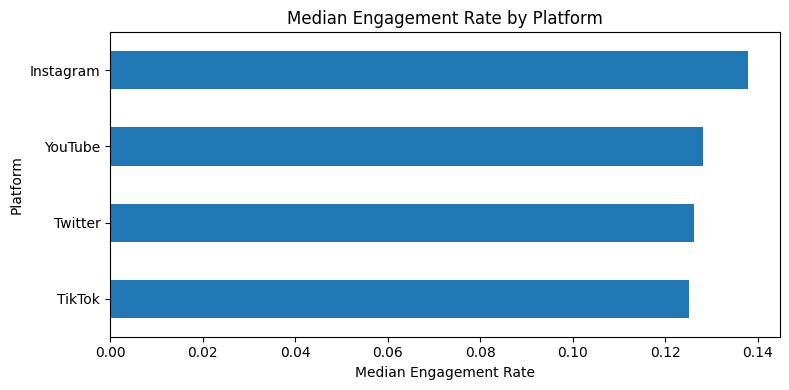

In [8]:
platform_summary["median_engagement_rate"].sort_values().plot(kind="barh", figsize=(8, 4))
plt.title("Median Engagement Rate by Platform")
plt.xlabel("Median Engagement Rate")
plt.ylabel("Platform")
plt.tight_layout()
plt.show()

### Platform Insight

Instagram has the highest **median engagement rate**, making it the strongest platform for a typical post in this dataset. The differences between platforms are modest when measured by the median, which suggests that platform choice alone does not fully explain performance. YouTube generates the largest total volume of views and engagement, partly because it has the greatest number of posts in the dataset.

## 5. Content Type Performance

In [9]:
content_summary = (
    df.groupby("content_type")
      .agg(
          posts=("post_id", "count"),
          total_views=("views", "sum"),
          total_engagement=("engagement_total", "sum"),
          mean_engagement_rate=("engagement_rate", "mean"),
          median_engagement_rate=("engagement_rate", "median"),
      )
      .sort_values("median_engagement_rate", ascending=False)
)

content_summary.style.format({
    "total_views": "{:,.0f}",
    "total_engagement": "{:,.0f}",
    "mean_engagement_rate": "{:.2%}",
    "median_engagement_rate": "{:.2%}",
})

,posts,total_views,total_engagement,mean_engagement_rate,median_engagement_rate
content_type,,,,,
Live Stream,855,"2,121,262,702","276,935,536",61.88%,13.54%
Reel,841,"2,130,478,961","278,869,160",48.75%,13.31%
Video,828,"2,060,899,340","273,304,522",48.82%,12.89%
Shorts,787,"1,956,758,015","253,870,907",80.63%,12.87%
Post,853,"2,110,609,731","279,360,350",49.81%,12.53%
Tweet,836,"2,090,323,471","272,074,453",52.07%,12.53%


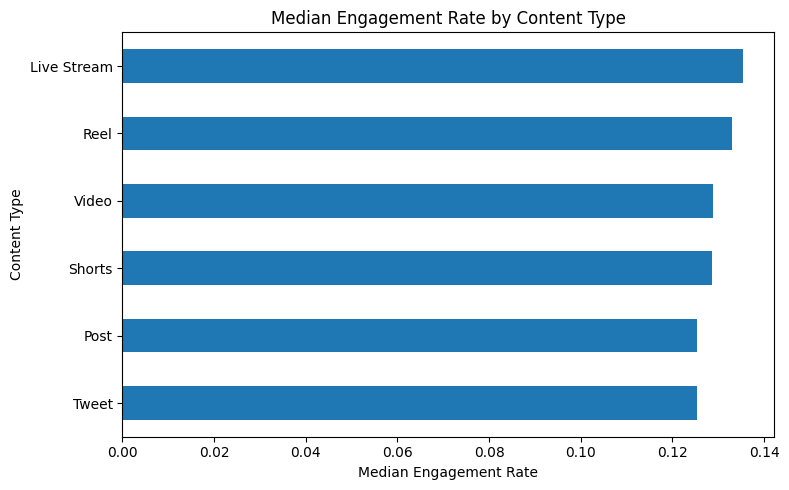

In [10]:
content_summary["median_engagement_rate"].sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Median Engagement Rate by Content Type")
plt.xlabel("Median Engagement Rate")
plt.ylabel("Content Type")
plt.tight_layout()
plt.show()

### Content Insight

Live streams have the highest median engagement rate, followed by reels and videos. Shorts rank first by **mean** engagement rate, but that result is driven by extreme observations. This distinction demonstrates why robust statistics are important when evaluating social media performance.

## 6. Engagement Mix by Platform

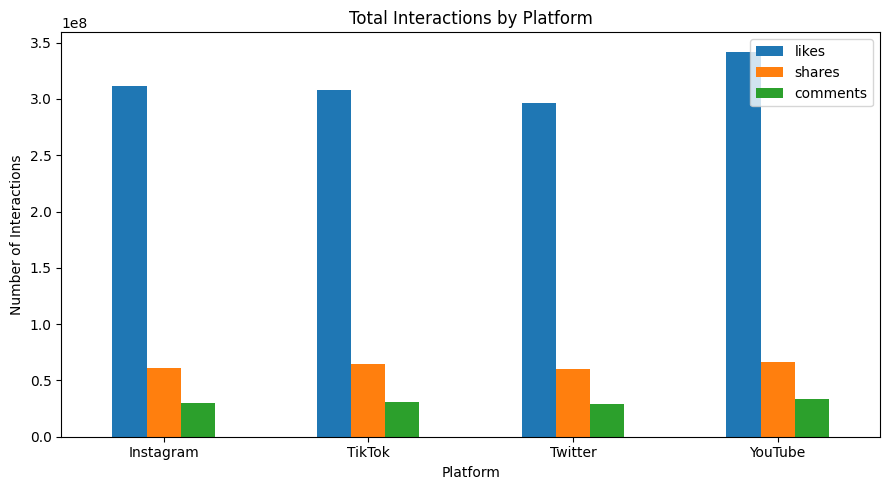

In [11]:
interaction_mix = (
    df.groupby("platform")[["likes", "shares", "comments"]]
      .sum()
      .sort_index()
)

interaction_mix.plot(kind="bar", figsize=(9, 5))
plt.title("Total Interactions by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Interactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Likes account for most interactions on every platform. Shares and comments contribute less volume but may represent stronger forms of audience intent. A real marketing campaign should therefore evaluate each interaction separately rather than relying only on one combined engagement metric.

## 7. SQL Validation

In [12]:
connection = sqlite3.connect(":memory:")
df.to_sql("social_posts", connection, index=False, if_exists="replace")

platform_sql = pd.read_sql_query(
    """
    SELECT
        platform,
        COUNT(*) AS posts,
        ROUND(AVG(engagement_rate), 4) AS mean_engagement_rate,
        SUM(engagement_total) AS total_engagement
    FROM social_posts
    GROUP BY platform
    ORDER BY mean_engagement_rate DESC;
    """,
    connection,
)

platform_sql

,platform,posts,mean_engagement_rate,total_engagement
0,Instagram,1212,0.6621,402853336
1,TikTok,1260,0.6387,403771628
2,YouTube,1324,0.5064,441830033
3,Twitter,1204,0.4654,385959931


In [13]:
content_sql = pd.read_sql_query(
    """
    SELECT
        content_type,
        COUNT(*) AS posts,
        ROUND(AVG(engagement_rate), 4) AS mean_engagement_rate,
        SUM(engagement_total) AS total_engagement
    FROM social_posts
    GROUP BY content_type
    ORDER BY mean_engagement_rate DESC;
    """,
    connection,
)

content_sql

,content_type,posts,mean_engagement_rate,total_engagement
0,Shorts,787,0.8063,253870907
1,Live Stream,855,0.6188,276935536
2,Tweet,836,0.5207,272074453
3,Post,853,0.4981,279360350
4,Video,828,0.4882,273304522
5,Reel,841,0.4875,278869160


The SQL results reproduce the mean-based rankings calculated in Pandas. The comparison also reinforces the earlier caution: mean engagement rates are useful for aggregate reporting, but they should be interpreted alongside medians and outlier checks.

## 8. Key Findings

1. **Instagram leads typical platform engagement.** It has the highest median engagement rate among the four platforms.
2. **YouTube leads in total scale.** It records the highest total views and total engagement, influenced in part by having the most observations.
3. **Live streams lead by median content performance.** Reels and videos follow closely.
4. **Shorts lead by mean engagement rate, but not by median.** Extreme values inflate their average, so this result should not be interpreted without the outlier context.
5. **Platform and format differences are narrower than the raw means suggest.** Marketing decisions should combine engagement quality, reach, audience, campaign goals, and cost.

## 9. Business Recommendations

- Use **Instagram** as a strong candidate for campaigns focused on consistent audience interaction.
- Maintain **YouTube** for campaigns where total reach and interaction volume are important.
- Test **live streams, reels, and videos** as priority formats, using controlled experiments to measure incremental impact.
- Treat unusually high engagement rates as potential outliers and validate them before allocating budget.
- Track likes, shares, comments, conversions, and cost separately instead of depending on one combined engagement metric.

## 10. Conclusion

This analysis shows how platform and content-format performance can change depending on the metric used. Instagram performs best for typical platform engagement, while YouTube provides the greatest overall scale. Live streams lead content types by median engagement, whereas Shorts appear strongest only when using an outlier-sensitive average.

The main business lesson is that marketing teams should combine robust statistics with campaign objectives before deciding where to invest. Future work could incorporate follower counts, advertising cost, conversions, audience demographics, and time-series trends to estimate return on marketing investment more directly.

---

### Repository Files

- `viral_social_media_analysis.ipynb` — complete analysis notebook
- `Cleaned_Viral_Social_Media_Trends.csv` — source dataset
- `sql/social_media_queries.sql` — optional standalone SQL queries